# 🔬 Physics & Sensitometry: Tone Reproduction

### Welcome, Imaging Scientists!
In previous labs, we looked at film and paper in isolation. But in the real world, a photograph is a complete *system*. Tone Reproduction is the scientific study of how the brightness of an original subject is translated into the final reflection density of a photographic print.

Our goal is to understand if the tonal relationships in the real world are accurately reproduced on the paper, and if not, where the distortions happen. To do this, we break the photographic journey into four distinct steps:
1. **Subject Luminance & Lens Flare**
2. **The Film Response (Negative)**
3. **The Enlarger & Paper Response (Print)**
4. **The Final Tone Reproduction Curve**

## Step 1: Subject Luminance & Lens Flare
The journey begins with the Subject Luminance Range (SVR), which is the difference between the brightest highlight and the darkest shadow in the real world. 

When this light enters your camera lens, it bounces around off the glass elements and the inside of the camera body. This scattered light is called **Flare**. 

Flare adds a uniform amount of non-image light to the entire frame. While a little bit of extra light doesn't noticeably affect the bright highlights, it profoundly affects the shadows! Flare acts as a "floor," lifting the shadows and destroying contrast in the dark areas of the image before the light even strikes the film.

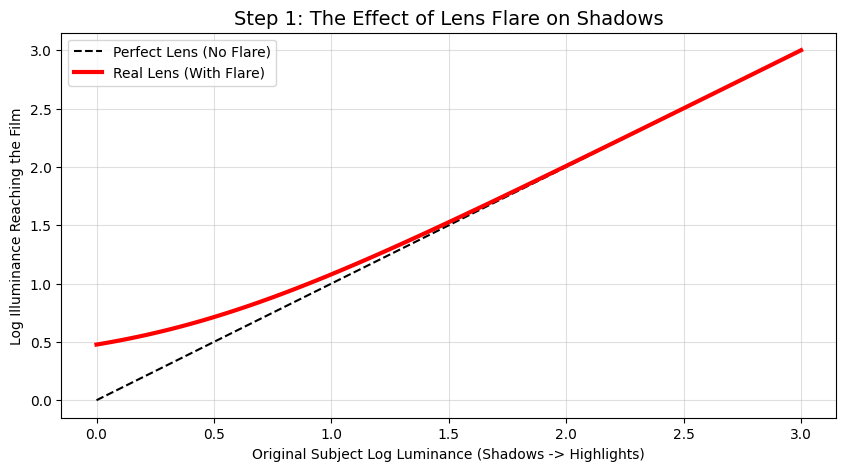

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_lens_flare():
    """
    Simulates how lens flare compresses shadow contrast.
    """
    # Real-world subject luminance (logarithmic scale from dark to bright)
    subject_log_luminance = np.linspace(0, 3, 100)
    subject_linear_luminance = 10 ** subject_log_luminance
    
    # Add a constant flare factor (e.g., 2 units of stray light)
    flare_factor = 2.0
    illuminance_with_flare = subject_linear_luminance + flare_factor
    
    # Convert back to log scale for photographic evaluation
    log_illuminance_with_flare = np.log10(illuminance_with_flare)
    
    plt.figure(figsize=(10, 5))
    plt.plot(subject_log_luminance, subject_log_luminance, 'k--', label="Perfect Lens (No Flare)")
    plt.plot(subject_log_luminance, log_illuminance_with_flare, 'r-', lw=3, label="Real Lens (With Flare)")
    
    plt.title("Step 1: The Effect of Lens Flare on Shadows", fontsize=14)
    plt.xlabel("Original Subject Log Luminance (Shadows -> Highlights)")
    plt.ylabel("Log Illuminance Reaching the Film")
    plt.grid(True, alpha=0.4)
    plt.legend()
    plt.show()

# Run the flare simulation
simulate_lens_flare()

## Step 2 & 3: The Film and The Paper
Once the flared light hits the film, it is recorded according to the film's **Characteristic Curve** (the H&D Curve). As we learned previously, film compresses the extreme shadows (the Toe) and extreme highlights (the Shoulder).

When we put that negative into an enlarger and shine light through it onto photographic paper, we encounter another curve. Photographic paper has a much shorter dynamic range than film, and its curve is much steeper. 

Furthermore, paper is a "positive" medium. A high density on the negative (dark silver) blocks light, resulting in a low density on the paper (white paper base).

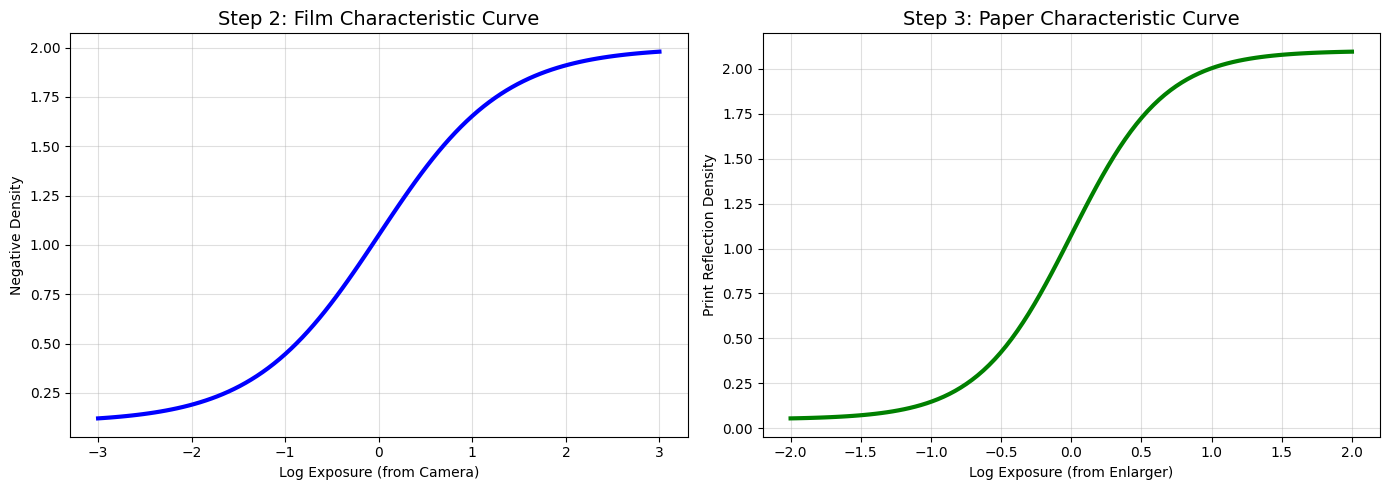

In [2]:
def simulate_film_and_paper_curves():
    """
    Simulates the individual characteristic curves of Film and Photographic Paper.
    """
    log_exposure = np.linspace(-3, 3, 100)
    
    # Film Curve (Negative) - Gentle toe and shoulder
    film_density = 0.1 + (2.0 - 0.1) / (1 + np.exp(-1.5 * log_exposure))
    
    # Paper Curve (Positive) - Steep, sharp toe and shoulder
    # Note: X-axis for paper is Log Exposure from the enlarger (which is inversely related to film density)
    paper_log_exposure = np.linspace(-2, 2, 100)
    paper_density = 0.05 + (2.1 - 0.05) / (1 + np.exp(-3.0 * paper_log_exposure))
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].plot(log_exposure, film_density, 'b-', lw=3)
    axes[0].set_title("Step 2: Film Characteristic Curve", fontsize=14)
    axes[0].set_xlabel("Log Exposure (from Camera)")
    axes[0].set_ylabel("Negative Density")
    axes[0].grid(True, alpha=0.4)
    
    axes[1].plot(paper_log_exposure, paper_density, 'g-', lw=3)
    axes[1].set_title("Step 3: Paper Characteristic Curve", fontsize=14)
    axes[1].set_xlabel("Log Exposure (from Enlarger)")
    axes[1].set_ylabel("Print Reflection Density")
    axes[1].grid(True, alpha=0.4)
    
    plt.tight_layout()
    plt.show()

# Run the film and paper simulation
simulate_film_and_paper_curves()

## Step 4: The Jones Quadrant Diagram
In 1920, L.A. Jones at Kodak invented a brilliant graphical method to tie all these steps together. By arranging the graphs in a four-quadrant box, we can trace a specific shadow or highlight from the real world, through the lens, onto the film, onto the paper, and finally see how it looks in the physical print.

The resulting mathematical curve is the **Tone Reproduction Curve**. 
* If the curve is a perfectly straight 45-degree line, the print is an exact, mathematically perfect reproduction of reality. 
* Because of flare, film toes, and paper shoulders, the line is *never* perfectly straight. The art of darkroom science is managing these distortions so the final image looks pleasing to the human eye.

Let's use Python to calculate the final Tone Reproduction Curve by passing data through all three physical constraints sequentially!

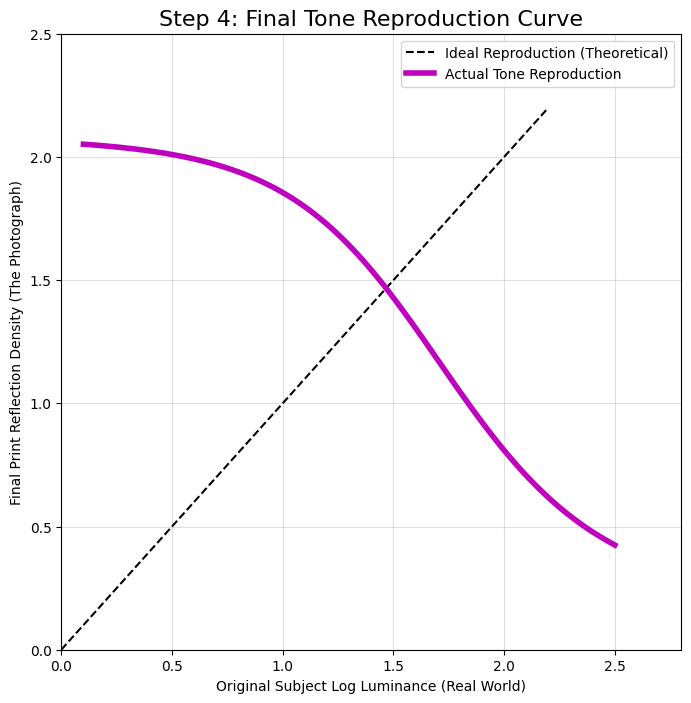

In [3]:
def simulate_tone_reproduction():
    """
    Simulates the full tone reproduction cycle: 
    Subject -> Flare -> Film -> Paper -> Final Print.
    """
    # 1. Subject Luminance (Log scale)
    subject_log_lum = np.linspace(0.1, 2.5, 100)
    
    # 2. Add Flare (Assume flare factor of 1.5)
    illuminance = (10 ** subject_log_lum) + 1.5
    camera_log_exp = np.log10(illuminance)
    
    # 3. Film Curve (Negative Density)
    # Using a simple logistic function to simulate film response
    film_density = 0.1 + 2.0 / (1 + np.exp(-1.5 * (camera_log_exp - 1.5)))
    
    # 4. Enlarger Exposure 
    # High film density = low paper exposure. We invert it.
    paper_log_exp = 2.5 - film_density
    
    # 5. Paper Curve (Final Print Density)
    # Steep response curve typical of photographic paper
    print_density = 0.05 + 2.1 / (1 + np.exp(-3.5 * (paper_log_exp - 1.2)))
    
    # Plotting the Final Tone Reproduction Curve
    plt.figure(figsize=(8, 8))
    
    # Ideal reproduction (1:1 mapping)
    ideal_line = np.linspace(0, 2.2, 100)
    plt.plot(ideal_line, ideal_line, 'k--', label="Ideal Reproduction (Theoretical)")
    
    # Actual reproduction
    plt.plot(subject_log_lum, print_density, 'm-', lw=4, label="Actual Tone Reproduction")
    
    plt.title("Step 4: Final Tone Reproduction Curve", fontsize=16)
    plt.xlabel("Original Subject Log Luminance (Real World)")
    plt.ylabel("Final Print Reflection Density (The Photograph)")
    plt.xlim(0, 2.8)
    plt.ylim(0, 2.5)
    plt.grid(True, alpha=0.4)
    plt.legend()
    plt.show()

# Run the Tone Reproduction simulation!
simulate_tone_reproduction()

### 🔍 Analysis: The S-Curve of Photography
Look at the final magenta line generated above. It is an "S-Curve". 

1. **The Shadows (Bottom Left):** The curve flattens out. Because of lens flare and the "toe" of the film, shadow details are compressed. They lack contrast compared to the real world.
2. **The Midtones (Center):** The curve is steep and relatively straight. Midtones are reproduced faithfully, often with slightly boosted contrast to compensate for the flat shadows and highlights.
3. **The Highlights (Top Right):** The curve flattens out again due to the "shoulder" of the paper. Bright highlights compress into pure white.

This final curve proves that a photograph is *not* an objective record of reality; it is a physical and chemical interpretation. Understanding this curve gives you absolute engineering control over that interpretation.